In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("online_data/weather/weather_city.csv")

In [3]:
df["time"] = pd.to_datetime(df["time"])

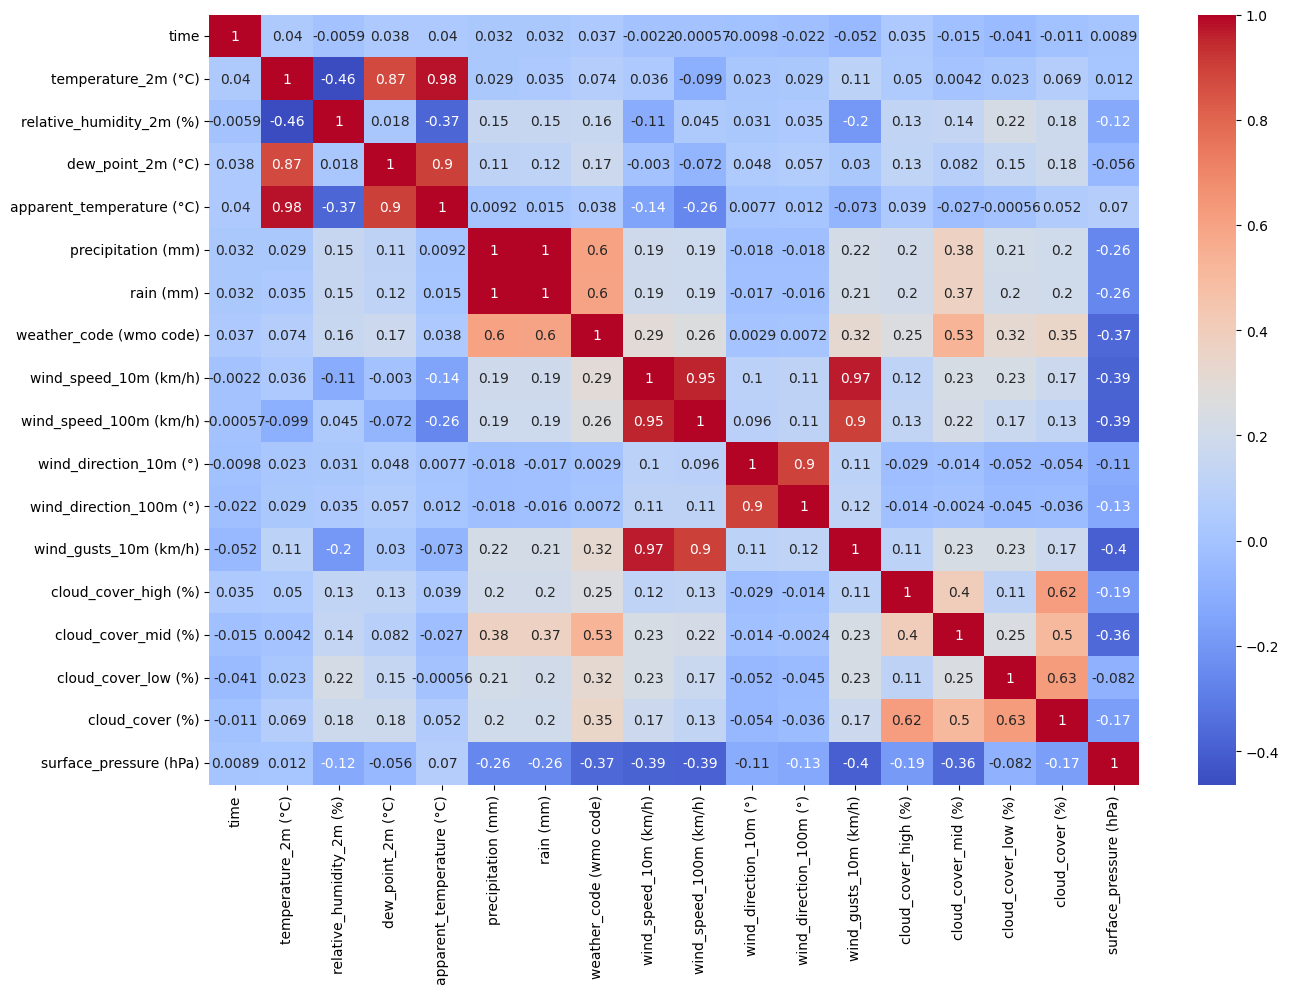

In [4]:
fig, ax = plt.subplots(figsize=(15, 10))  # Set the figure size
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=ax)
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

def hierarchical_corr_feature_selection_unsupervised(df, corr_threshold=0.75):
    X = df.copy()
    corr = X.corr().abs()

    # convert correlation to distance
    dist = 1 - corr
    dist_condensed = squareform(dist.values, checks=False)

    # hierarchical clustering
    Z = linkage(dist_condensed, method="average")
    clusters = fcluster(Z, t=1 - corr_threshold, criterion="distance")

    cluster_map = {}
    for feature, cluster_id in zip(X.columns, clusters):
        cluster_map.setdefault(cluster_id, []).append(feature)

    selected_features = []

    for cluster_id, features in cluster_map.items():
        sub_corr = corr.loc[features, features]
        avg_corr = sub_corr.mean(axis=1)
        best_feature = avg_corr.idxmin()

        selected_features.append(best_feature)

    return selected_features

selected_features = hierarchical_corr_feature_selection_unsupervised(df.drop(columns=["time"]), corr_threshold=0.75)

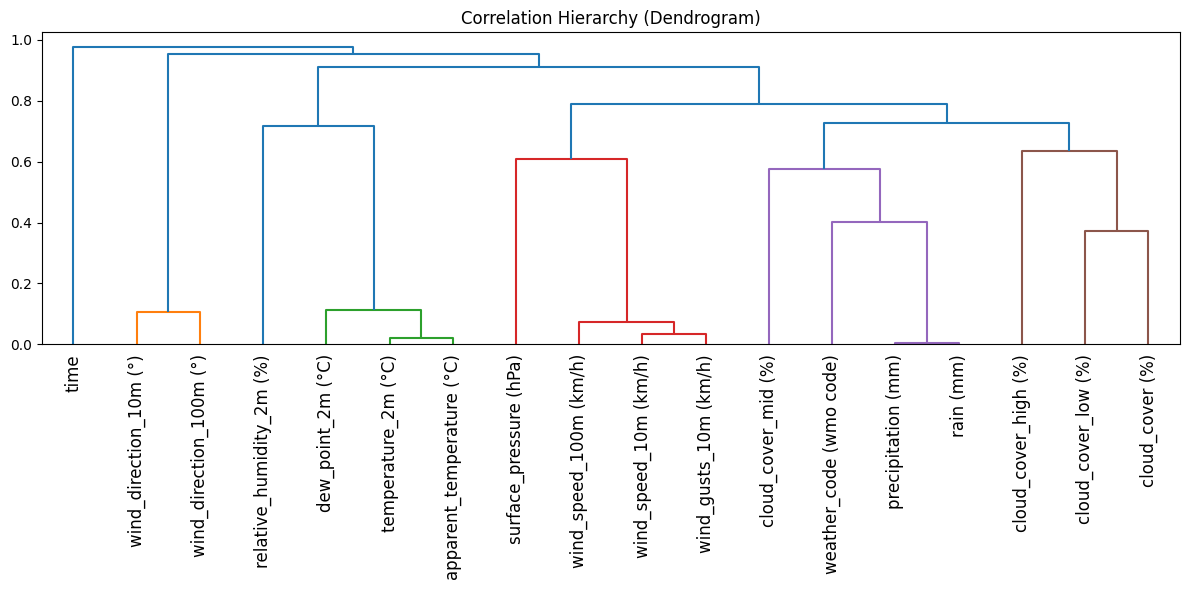

In [6]:
def plot_correlation_hierarchy(df, method="average"):
    """
    df: DataFrame with features only (no target)
    method: linkage method ('average', 'complete', 'ward', etc.)
    """

    # 1) Compute absolute correlation matrix
    corr = df.corr().abs()

    # 2) Convert correlation to distance
    dist = 1 - corr
    dist_condensed = squareform(dist.values, checks=False)

    # 3) Hierarchical clustering
    Z = linkage(dist_condensed, method=method)

    # 4) Plot dendrogram
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=df.columns, leaf_rotation=90)
    plt.title("Correlation Hierarchy (Dendrogram)")
    plt.tight_layout()
    plt.show()

    return Z
Z = plot_correlation_hierarchy(df)


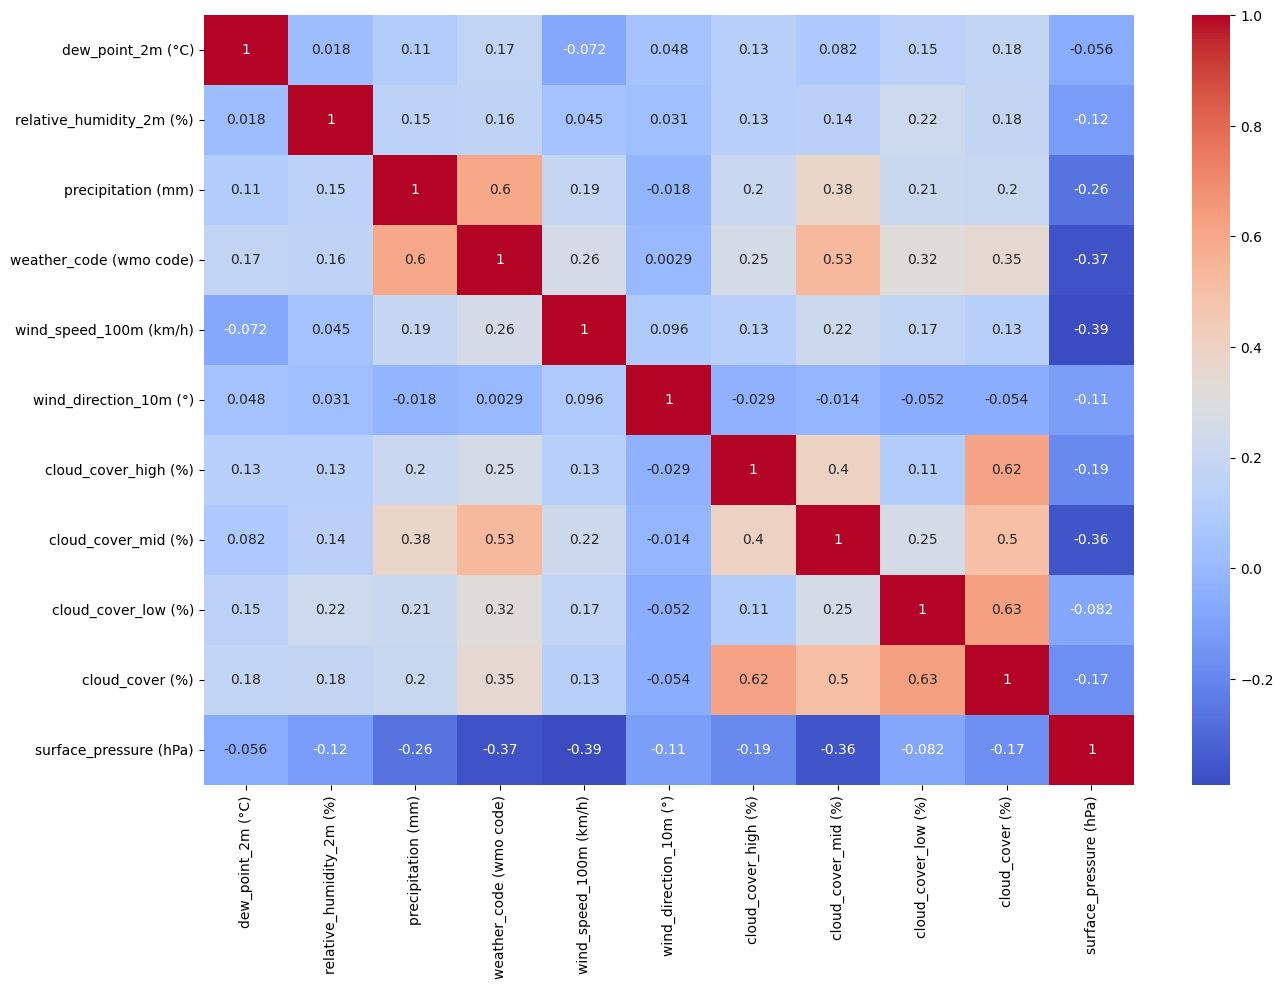

In [11]:
fig, ax = plt.subplots(figsize=(15, 10))  # Set the figure size
sns.heatmap(df[selected_features].corr(), annot=True, cmap="coolwarm", ax=ax)
plt.show()

In [15]:
df_selected = df[selected_features]
df_selected["timestamp"] = df["time"]

In [16]:
import pickle
with open("weather_global_2014_2025.pkl", "wb") as f:
    pickle.dump(df_selected, f)